In [39]:
import torch
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time

import matplotlib.pyplot as plt
import pandas as pd

In [40]:
transform_data = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.4914 , 0.4822 , 0.4465) , (0.2023 , 0.1994 , 0.2010))])
train_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_data)
test_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_data)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


NUM_EPOCH = 10
BATCH_SIZES = [20, 50, 100, 200, 500, 1000]
alpha = 0.01

/home/takeshi-stormer/Homework-Repository/env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Using device: cuda


In [41]:
import torch.nn as nn   
import torch.nn.functional as F
class SimpleCIFAR10CNN(nn.Module):
    def __init__(self):
        super(SimpleCIFAR10CNN , self).__init__()
        # Layer 1: Conv2D
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        # Layers 2 & 4: Max Pooling ( Reduces H and W by half )
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Layer 3: Conv2D
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        # Layer 6: Fully Connected / Dense
        self.fc1 = nn.Linear(in_features=32 * 8 * 8, out_features=128)
        # Layer 7: Fully Connected
        self.fc2 = nn.Linear(in_features=128, out_features=10)
        
    def forward(self, x):
        # Layer 1 & 2: Conv -> ReLU -> MaxPool
        x = self.pool(F.relu(self.conv1(x)))
        # Layer 3 & 4: Conv -> ReLU -> MaxPool
        x = self.pool(F.relu(self.conv2(x)))
        # Layer 5: Flatten
        # Reshapes the 3 D feature maps into a 1 D vector per sample .
        # start_dim = 1 ensures we preserve the batch dimension .
        x = torch.flatten(x, start_dim=1)
        # Layer 6: Dense -> ReLU
        x = F.relu(self.fc1(x))
        # Layer 7: Dense Output ( Logits )
        x = self.fc2(x)
        return x
    
import numpy as np
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Sets seed for all available GPUs
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [42]:
results = {}
set_seed(42)
criterion = nn.CrossEntropyLoss(reduction='mean')
for BATCH_SIZE in BATCH_SIZES:
    train_loader = torch.utils.data.DataLoader(train_raw, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = torch.utils.data.DataLoader(test_raw, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    Net = SimpleCIFAR10CNN().to(device)
    Net.train()
    optimizer = optim.SGD(Net.parameters(), lr=alpha)
    training_runtime = 0.0
    accuracy = 0.0
    avg_train_loss = 0.0 
    for epoch in range(NUM_EPOCH):
        epoch_loss = 0.0
        start_time = time.perf_counter()
        for images, labels in train_loader:
            optimizer.zero_grad()
            images, labels = images.to(device), labels.to(device)
            loss = criterion(Net(images), labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        end_time = time.perf_counter()
        training_runtime += (end_time - start_time)

        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{NUM_EPOCH}")
            correct = 0
            total = 0
            with torch.no_grad():
                for images, labels in test_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = Net(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
            
            accuracy = 100 * correct / total
            avg_train_loss = epoch_loss / len(train_loader)
            print(f"Batch Size: {BATCH_SIZE}, Epoch: {epoch+1}, Avg Train Loss: {avg_train_loss:.4f}, Test Accuracy: {accuracy:.2f}%")
    print(f"Batch Size: {BATCH_SIZE}, Avg Train Loss: {avg_train_loss:.4f}, Total Training Time: {training_runtime:.2f} seconds\n")

    Net.eval()
    start_time = time.perf_counter()
    
    with torch.no_grad():
        correct = 0
        total = 0
        for test_images, test_labels in test_loader:
            test_images, test_labels = test_images.to(device), test_labels.to(device)
            
            test_outputs = Net(test_images)
            _, predicted = torch.max(test_outputs.data, 1)
            
            total += test_labels.size(0)
            correct += (predicted == test_labels).sum().item()

    accuracy = 100 * correct / total
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    results[BATCH_SIZE] = (avg_train_loss, training_runtime, accuracy, elapsed_time)
    print(f"Batch Size: {BATCH_SIZE}, Test Accuracy: {accuracy:.2f}%, Testing Time: {elapsed_time:.2f} seconds\n")
print("Batch Size | Avg Train Loss | Training Time (s) | Test Accuracy (%) | Testing Time (s)")
for batch_size, result in results.items():
    print(f"{batch_size:10} | {result[0]:14.4f} | {result[1]:17.2f} | {result[2]:17.2f} | {result[3]:17.2f}")


Epoch 2/10
Batch Size: 20, Epoch: 2, Avg Train Loss: 1.2259, Test Accuracy: 59.45%
Epoch 4/10
Batch Size: 20, Epoch: 4, Avg Train Loss: 0.9360, Test Accuracy: 66.52%
Epoch 6/10
Batch Size: 20, Epoch: 6, Avg Train Loss: 0.7617, Test Accuracy: 69.03%
Epoch 8/10
Batch Size: 20, Epoch: 8, Avg Train Loss: 0.6124, Test Accuracy: 68.91%
Epoch 10/10
Batch Size: 20, Epoch: 10, Avg Train Loss: 0.4795, Test Accuracy: 68.64%
Batch Size: 20, Avg Train Loss: 0.4795, Total Training Time: 22.01 seconds

Batch Size: 20, Test Accuracy: 68.64%, Testing Time: 0.44 seconds

Epoch 2/10
Batch Size: 50, Epoch: 2, Avg Train Loss: 1.4476, Test Accuracy: 52.34%
Epoch 4/10
Batch Size: 50, Epoch: 4, Avg Train Loss: 1.1689, Test Accuracy: 59.20%
Epoch 6/10
Batch Size: 50, Epoch: 6, Avg Train Loss: 1.0090, Test Accuracy: 63.33%
Epoch 8/10
Batch Size: 50, Epoch: 8, Avg Train Loss: 0.8966, Test Accuracy: 66.74%
Epoch 10/10
Batch Size: 50, Epoch: 10, Avg Train Loss: 0.8030, Test Accuracy: 67.61%
Batch Size: 50, Avg Tra

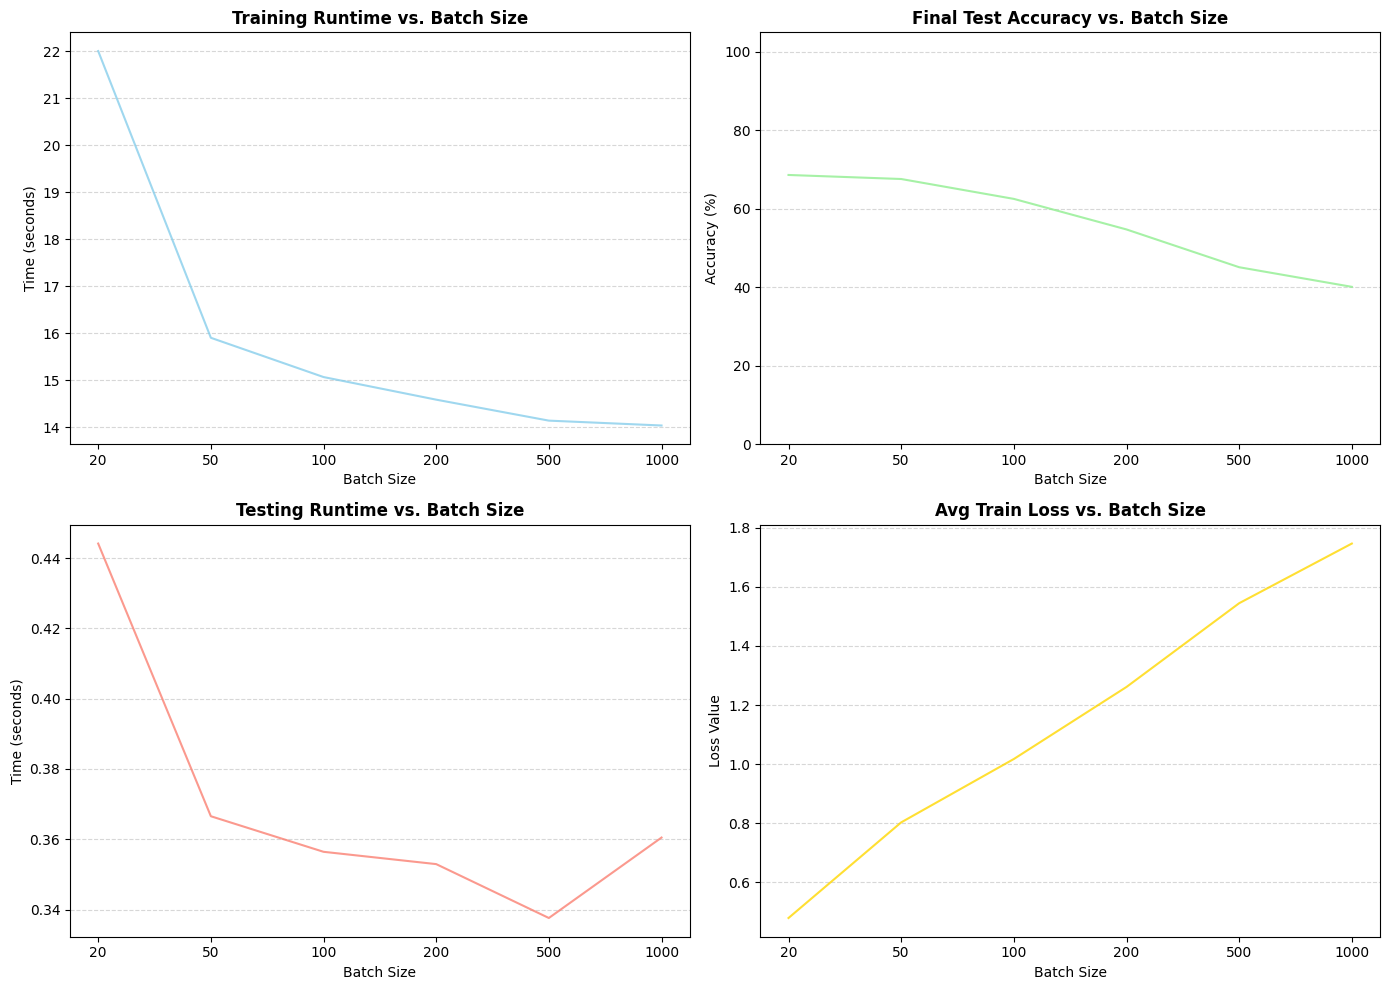

In [43]:
batch_sizes = sorted(results.keys())
categories = [str(bs) for bs in batch_sizes]

train_losses = [results[bs][0] for bs in batch_sizes]
train_runtimes = [results[bs][1] for bs in batch_sizes]
test_accuracies = [results[bs][2] for bs in batch_sizes]
test_runtimes = [results[bs][3] for bs in batch_sizes]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(categories, train_runtimes, color='skyblue', alpha=0.8)
axes[0, 0].set_title('Training Runtime vs. Batch Size', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Batch Size', fontsize=10)
axes[0, 0].set_ylabel('Time (seconds)', fontsize=10)
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.5)

axes[0, 1].plot(categories, test_accuracies, color='lightgreen', alpha=0.8)
axes[0, 1].set_title('Final Test Accuracy vs. Batch Size', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Batch Size', fontsize=10)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=10)
axes[0, 1].set_ylim(0, 105) 
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)

axes[1, 0].plot(categories, test_runtimes, color='salmon', alpha=0.8)
axes[1, 0].set_title('Testing Runtime vs. Batch Size', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Batch Size', fontsize=10)
axes[1, 0].set_ylabel('Time (seconds)', fontsize=10)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1, 1].plot(categories, train_losses, color='gold', alpha=0.8)
axes[1, 1].set_title('Avg Train Loss vs. Batch Size', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Batch Size', fontsize=10)
axes[1, 1].set_ylabel('Loss Value', fontsize=10)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [44]:
df = pd.DataFrame.from_dict(
    results, 
    orient='index', 
    columns=['Avg Train Loss', 'Train Runtime (s)', 'Test Accuracy (%)', 'Test Runtime (s)']
)

df.index.name = 'Batch Size'

df.to_csv('batch_size_results.csv')
print("Results saved to batch_size_results.csv")

Results saved to batch_size_results.csv


**Short Analysis**

It appears that the smaller the batch size, the better the accuracy and loss values. However, due to the fact that there is an increase in runtime for smaller batch sizes, most likely attributed to the runtime overhead caused by the for loops, and given the drop off in accuracy as batch sizes increase, the maximum batch size that is somewhat optimal appears to be 50 (the batch size that didn't see a big difference in accuracy, but is considerably faster).

On a side note, we do see that the testing runtime for the batch size of 500 is the lowest, and then it increases again for a batch size of 1,000. This can potentially be attributed to overhead caused by moving large quantities of images to VRAM. However, this doesn't appear to be an issue for the training runtime.